# Task 0 — Data Exploratory Analysis (EDA) sul Dataset QEvasion

Questo notebook analizza il dataset utilizzato per il fine-tuning di Llama 3.1. 
L'obiettivo è estrarre statistiche utili sulle distribuzioni delle etichette (Clarity ed Evasion), calcolare la lunghezza media dei testi e visualizzare la correlazione tra le tecniche di evasione e le macro-categorie di chiarezza.

In [4]:
# ============================================================
# CELLA 1 — Setup e Importazione Librerie
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

# Stile dei grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Configurazione dei percorsi e rilevamento ambiente (Colab / Locale)
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Ambiente Google Colab rilevato. Google Drive montato con successo.")
    
    # Percorso base su Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"
    
except ImportError:
    print("Ambiente locale rilevato.")
    
    # Percorso base locale (impostato alla root del progetto corrente)
    BASE_DIR = ".."
    REPO_DIR = os.path.join(BASE_DIR, "CLARITY")

# Percorso per il salvataggio dei grafici e dei risultati dell'analisi
ANALYSIS_DIR = os.path.join(BASE_DIR, "analisi_dataset")
os.makedirs(ANALYSIS_DIR, exist_ok=True)
print(f"Directory di output impostata su: {ANALYSIS_DIR}")

Ambiente locale rilevato.
Directory di output impostata su: ./analisi_dataset


In [5]:
# ============================================================
# CELLA 2 — Caricamento Dataset e Conversione in Pandas
# ============================================================

# Costruzione dinamica dei percorsi basata sull'ambiente rilevato
# (Rimosso "CLARITY" perché il notebook è già nella root del progetto)
DATASET_TRAIN_PATH = os.path.join(REPO_DIR, "dataset", "QEvasion", "train")
DATASET_TEST_PATH  = os.path.join(REPO_DIR, "dataset", "QEvasion", "test")

print("Caricamento dataset in corso dai seguenti percorsi:")
print(f" -> {DATASET_TRAIN_PATH}")
print(f" -> {DATASET_TEST_PATH}")

dataset_train = load_from_disk(DATASET_TRAIN_PATH)
dataset_test  = load_from_disk(DATASET_TEST_PATH)

# Conversione in DataFrame Pandas per l'analisi statistica
df_train = dataset_train.to_pandas()
df_test  = dataset_test.to_pandas()

# Aggiunta colonna per l'identificazione dello split
df_train['split'] = 'Train'
df_test['split'] = 'Test'

# Unione in un singolo DataFrame
df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset caricato con successo.")
print(f" - Esempi in Train: {len(df_train)}")
print(f" - Esempi in Test:  {len(df_test)}")
print(f" - Totale Esempi:   {len(df_all)}\n")

display(df_all.head(3))

Caricamento dataset in corso dai seguenti percorsi:
 -> ./dataset/QEvasion/train
 -> ./dataset/QEvasion/test
Dataset caricato con successo.
 - Esempi in Train: 3448
 - Esempi in Test:  308
 - Totale Esempi:   3756



,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,split
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,...,NaN,NaN,NaN,False,False,False,0,Clear Reply,Explicit,Train
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,...,NaN,NaN,NaN,False,False,False,1,Ambivalent,General,Train
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,...,NaN,NaN,NaN,False,False,False,2,Ambivalent,Partial/half-answer,Train


--- Distribuzione Etichette di Chiarezza (Task 1) ---
clarity_label
Ambivalent         2246
Clear Reply        1131
Clear Non-Reply     379
Name: count, dtype: int64

Percentuali:
clarity_label
Ambivalent         59.797657
Clear Reply        30.111821
Clear Non-Reply    10.090522
Name: proportion, dtype: float64


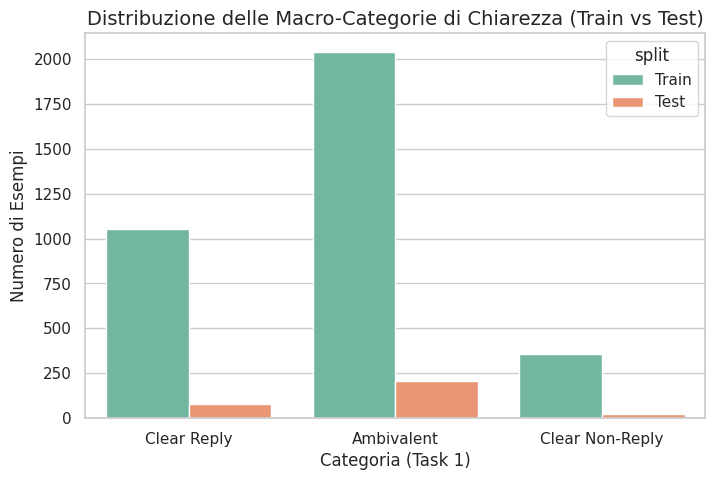

In [6]:
# ============================================================
# CELLA 3 — Distribuzione Macro-Categorie (Task 1: Clarity)
# ============================================================

print("--- Distribuzione Etichette di Chiarezza (Task 1) ---")
clarity_counts = df_all['clarity_label'].value_counts()
print(clarity_counts)
print(f"\nPercentuali:\n{df_all['clarity_label'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_all, x='clarity_label', hue='split', palette='Set2', 
                   order=["Clear Reply", "Ambivalent", "Clear Non-Reply"])

plt.title('Distribuzione delle Macro-Categorie di Chiarezza (Train vs Test)', fontsize=14)
plt.xlabel('Categoria (Task 1)', fontsize=12)
plt.ylabel('Numero di Esempi', fontsize=12)

# Salva il grafico
plt.savefig(f"{ANALYSIS_DIR}/distribuzione_clarity.png", bbox_inches='tight', dpi=300)
plt.show()

--- Distribuzione Tecniche di Evasione (Task 2) ---
evasion_label
Explicit               1052
Dodging                 706
Implicit                488
General                 386
Deflection              381
                        308
Declining to answer     145
Claims ignorance        119
Clarification            92
Partial/half-answer      79
Name: count, dtype: int64


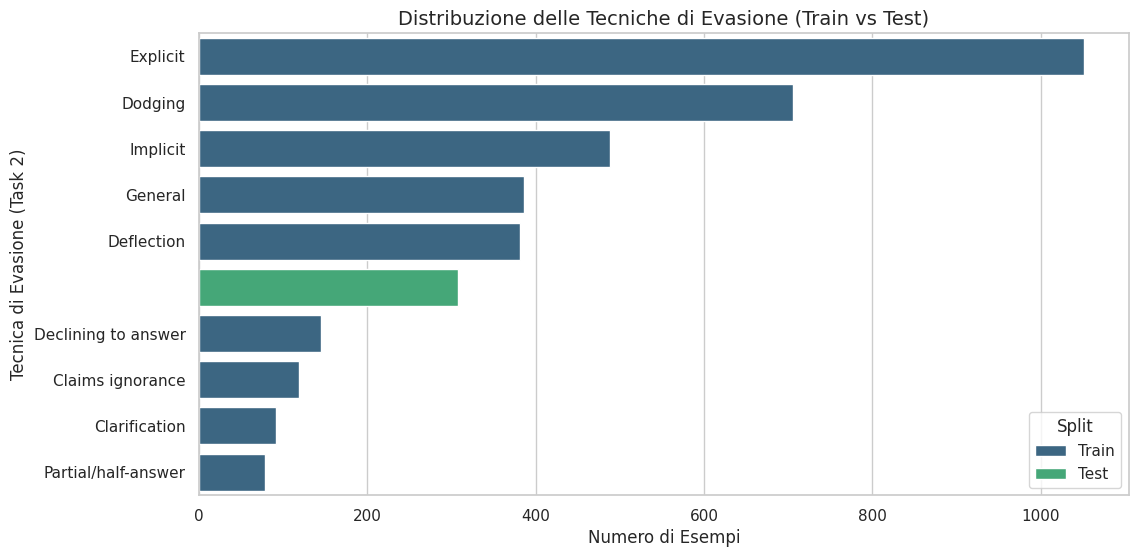

In [7]:
# ============================================================
# CELLA 4 — Distribuzione Tecniche di Evasione (Task 2)
# ============================================================

print("--- Distribuzione Tecniche di Evasione (Task 2) ---")
evasion_counts = df_all['evasion_label'].value_counts()
print(evasion_counts)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_all, y='evasion_label', hue='split', palette='viridis', 
                   order=evasion_counts.index)

plt.title('Distribuzione delle Tecniche di Evasione (Train vs Test)', fontsize=14)
plt.xlabel('Numero di Esempi', fontsize=12)
plt.ylabel('Tecnica di Evasione (Task 2)', fontsize=12)
plt.legend(title='Split', loc='lower right')

plt.savefig(f"{ANALYSIS_DIR}/distribuzione_evasion.png", bbox_inches='tight', dpi=300)
plt.show()

--- Statistiche Lunghezza Testi (Numero di Parole) ---


,word_count_question,word_count_answer
count,3756.000000,3756.000000
mean,61.256922,296.256656
std,58.024103,298.274560
min,3.000000,1.000000
25%,23.000000,62.000000
50%,51.000000,213.000000
75%,81.000000,440.000000
max,780.000000,2117.000000


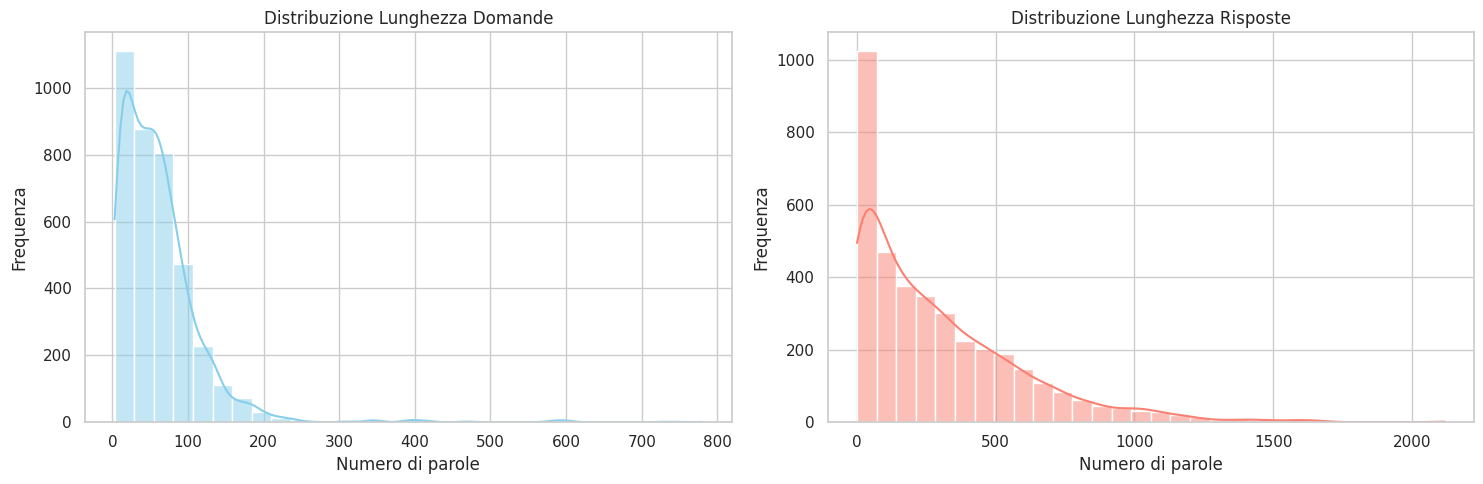

In [8]:
# ============================================================
# CELLA 5 — Analisi della Lunghezza dei Testi (Word Count)
# ============================================================

# Calcoliamo il numero di parole per domanda e risposta
df_all['word_count_question'] = df_all['interview_question'].apply(lambda x: len(str(x).split()))
df_all['word_count_answer']   = df_all['interview_answer'].apply(lambda x: len(str(x).split()))

print("--- Statistiche Lunghezza Testi (Numero di Parole) ---")
display(df_all[['word_count_question', 'word_count_answer']].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma Domande
sns.histplot(df_all['word_count_question'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribuzione Lunghezza Domande')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')

# Istogramma Risposte
sns.histplot(df_all['word_count_answer'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribuzione Lunghezza Risposte')
axes[1].set_xlabel('Numero di parole')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.savefig(f"{ANALYSIS_DIR}/lunghezza_testi.png", bbox_inches='tight', dpi=300)
plt.show()

--- Crosstab: Evasion Label vs Clarity Label ---


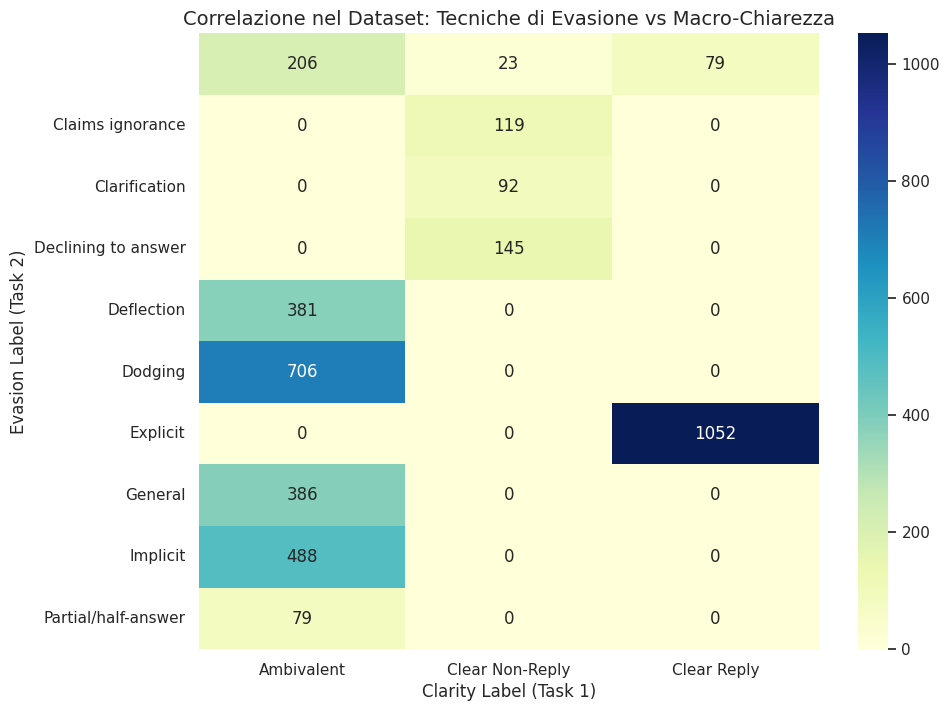

Analisi completata! Grafici e dati salvati in: ./analisi_dataset


In [9]:
# ============================================================
# CELLA 6 — Matrice di Correlazione (Task 2 -> Task 1)
# ============================================================
# Vogliamo vedere esattamente come le etichette di Evasione si 
# traducono in etichette di Chiarezza nel Dataset Reale (Ground Truth).

print("--- Crosstab: Evasion Label vs Clarity Label ---")
crosstab_df = pd.crosstab(df_all['evasion_label'], df_all['clarity_label'])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Correlazione nel Dataset: Tecniche di Evasione vs Macro-Chiarezza', fontsize=14)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Evasion Label (Task 2)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_correlazione_t1_t2.png", bbox_inches='tight', dpi=300)
plt.show()

# Salvataggio del dataset con le statistiche calcolate
df_all.to_csv(f"{ANALYSIS_DIR}/dataset_statistiche_complete.csv", index=False)
print(f"Analisi completata! Grafici e dati salvati in: {ANALYSIS_DIR}")